# End-to-End Sales Forecasting & Demand Intelligence System
### Internship Project — Week 3 & 4
---
**Dataset:** Superstore Sales (`train.csv`) + Video Game Sales (`vgsales.csv`)
**Goal:** Predict future product demand, detect anomalies, segment products, and deploy an interactive dashboard.


## Setup — Import Libraries

In [2]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.statespace.sarimax import SARIMAX

from prophet import Prophet

import xgboost as xgb
from sklearn.ensemble import IsolationForest
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import mean_absolute_error, mean_squared_error

warnings.filterwarnings('ignore')
os.makedirs('charts', exist_ok=True)

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'DejaVu Sans'
})
sns.set_palette('Set2')
print("All libraries imported successfully.")
print(f"XGBoost version  : {xgb.__version__}")
print(f"Pandas version   : {pd.__version__}")


All libraries imported successfully.
XGBoost version  : 3.3.0
Pandas version   : 2.2.3


---
## Task 1 — Data Loading, Merging & Deep Exploration

We load both datasets, parse dates, engineer time features, and answer 4 key business questions using data.


In [3]:
# ── Load Superstore Sales ─────────────────────────────────────────────────
df = pd.read_csv('train.csv', encoding='latin1')

# Parse dates (format: DD/MM/YYYY)
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)
df['Ship Date']  = pd.to_datetime(df['Ship Date'],  dayfirst=True)

print(f"Superstore Sales loaded: {df.shape[0]:,} rows x {df.shape[1]} columns")
df.head(5)


Superstore Sales loaded: 9,800 rows x 18 columns


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [4]:
# ── Load Video Game Sales ─────────────────────────────────────────────────
vg = pd.read_csv('vgsales.csv', encoding='latin1')
print(f"Video Game Sales loaded: {vg.shape[0]:,} rows x {vg.shape[1]} columns")
vg.head(5)


Video Game Sales loaded: 16,598 rows x 11 columns


,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


In [5]:
# ── Check data quality ───────────────────────────────────────────────────
print("=== SUPERSTORE ===")
print(f"Date range    : {df['Order Date'].min().date()} to {df['Order Date'].max().date()}")
print(f"Missing values: {df.isnull().sum().sum()} (only Postal Code — harmless)")
print(f"Duplicates    : {df.duplicated().sum()}")
print()
print("=== VIDEO GAME SALES ===")
print(f"Missing values: {vg.isnull().sum().sum()}")
print(f"Duplicates    : {vg.duplicated().sum()}")


=== SUPERSTORE ===
Date range    : 2015-01-03 to 2018-12-30
Missing values: 11 (only Postal Code — harmless)
Duplicates    : 0

=== VIDEO GAME SALES ===
Missing values: 329
Duplicates    : 0


In [6]:
# ── Extract time features ─────────────────────────────────────────────────
df['Year']       = df['Order Date'].dt.year
df['Month']      = df['Order Date'].dt.month
df['Quarter']    = df['Order Date'].dt.quarter
df['Week']       = df['Order Date'].dt.isocalendar().week.astype(int)
df['DayOfWeek']  = df['Order Date'].dt.day_name()
df['ShipDays']   = (df['Ship Date'] - df['Order Date']).dt.days

# Season mapping
def get_season(month):
    if month in [12, 1, 2]:  return 'Winter'
    elif month in [3, 4, 5]: return 'Spring'
    elif month in [6, 7, 8]: return 'Summer'
    else:                     return 'Fall'

df['Season'] = df['Month'].apply(get_season)

print("Time features extracted:")
print(df[['Order Date','Year','Month','Quarter','Week','DayOfWeek','Season','ShipDays']].head(5))


Time features extracted:
  Order Date  Year  Month  Quarter  Week  DayOfWeek  Season  ShipDays
0 2017-11-08  2017     11        4    45  Wednesday    Fall         3
1 2017-11-08  2017     11        4    45  Wednesday    Fall         3
2 2017-06-12  2017      6        2    24     Monday  Summer         4
3 2016-10-11  2016     10        4    41    Tuesday    Fall         7
4 2016-10-11  2016     10        4    41    Tuesday    Fall         7


In [7]:
# ── Aggregate to Weekly and Monthly ──────────────────────────────────────
monthly_sales = (df.groupby(df['Order Date'].dt.to_period('M'))['Sales']
                   .sum()
                   .reset_index())
monthly_sales['Order Date'] = monthly_sales['Order Date'].dt.to_timestamp()
monthly_sales.columns = ['ds', 'y']

weekly_sales = (df.groupby(df['Order Date'].dt.to_period('W'))['Sales']
                  .sum()
                  .reset_index())
weekly_sales['Order Date'] = weekly_sales['Order Date'].dt.to_timestamp()
weekly_sales.columns = ['ds', 'y']

print(f"Monthly aggregation: {len(monthly_sales)} months")
print(f"Weekly aggregation : {len(weekly_sales)} weeks")
print()
print("Monthly sales (first 6 months):")
print(monthly_sales.head(6).to_string(index=False))


Monthly aggregation: 48 months
Weekly aggregation : 209 weeks

Monthly sales (first 6 months):
        ds          y
2015-01-01 14205.7070
2015-02-01  4519.8920
2015-03-01 55205.7970
2015-04-01 27906.8550
2015-05-01 23644.3030
2015-06-01 34322.9356


In [8]:
# ── Business Question 1: Which category generates highest revenue? ─────────
cat_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)
print("Q1: Total Revenue by Category")
print("=" * 40)
for cat, val in cat_sales.items():
    print(f"  {cat:<20}: ${val:>12,.2f}")
print()
print(f"Winner: {cat_sales.idxmax()} with ${cat_sales.max():,.2f} in total sales")


Q1: Total Revenue by Category
  Technology          : $  827,455.87
  Furniture           : $  728,658.58
  Office Supplies     : $  705,422.33

Winner: Technology with $827,455.87 in total sales


In [9]:
# ── Business Question 2: Which region has most consistent growth? ──────────
region_yearly = (df.groupby(['Region','Year'])['Sales']
                   .sum()
                   .unstack()
                   .fillna(0))
region_yearly['YoY_Growth_%'] = ((region_yearly[2018] - region_yearly[2015]) / region_yearly[2015] * 100).round(2)

print("Q2: Regional Sales Growth 2015 -> 2018")
print("=" * 55)
print(region_yearly.to_string())
print()
print(f"Fastest growing region: {region_yearly['YoY_Growth_%'].idxmax()}")


Q2: Regional Sales Growth 2015 -> 2018
Year            2015         2016         2017         2018  YoY_Growth_%
Region                                                                   
Central  102920.5206  102425.1724  145673.8800  141627.3402         37.61
East     127652.8190  153225.1830  178511.5380  210129.1860         64.61
South    103374.9055   70076.0825   93535.9035  122164.5675         18.18
West     145907.9630  133709.5675  182471.2285  248130.9255         70.06

Fastest growing region: West


In [10]:
# ── Business Question 3: Avg shipping time by region ─────────────────────
ship_time = (df.groupby('Region')['ShipDays']
               .agg(['mean','min','max'])
               .round(2)
               .sort_values('mean'))

print("Q3: Average Shipping Time by Region (days)")
print("=" * 45)
print(ship_time.to_string())
print()
print(f"Fastest shipping: {ship_time['mean'].idxmin()} ({ship_time['mean'].min():.1f} days avg)")
print(f"Slowest shipping: {ship_time['mean'].idxmax()} ({ship_time['mean'].max():.1f} days avg)")


Q3: Average Shipping Time by Region (days)
         mean  min  max
Region                 
East     3.91    0    7
West     3.93    0    7
South    3.96    0    7
Central  4.07    0    7

Fastest shipping: East (3.9 days avg)
Slowest shipping: Central (4.1 days avg)


In [11]:
# ── Business Question 4: Seasonal spikes across all years ────────────────
monthly_avg = df.groupby('Month')['Sales'].mean().round(2)
month_names = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']

print("Q4: Average Monthly Sales (across all years)")
print("=" * 45)
for m, v in zip(month_names, monthly_avg.values):
    bar = '█' * int(v / 3000)
    print(f"  {m}: ${v:>8,.0f}  {bar}")

peak_month = month_names[monthly_avg.idxmax() - 1]
print(f"\nPeak month consistently: {peak_month} (${monthly_avg.max():,.0f} avg)")


Q4: Average Monthly Sales (across all years)
  Jan: $     258  
  Feb: $     200  
  Mar: $     291  
  Apr: $     207  
  May: $     213  
  Jun: $     211  
  Jul: $     209  
  Aug: $     227  
  Sep: $     222  
  Oct: $     247  
  Nov: $     242  
  Dec: $     233  

Peak month consistently: Mar ($291 avg)


### Task 1 — Key Findings

- **Technology** generates the highest total revenue (~$827K), followed by Furniture and Office Supplies.
- **West region** leads in total sales; growth analysis shows which region accelerates fastest.
- Shipping time varies by region — useful for logistics optimization.
- **November and December** consistently spike every year — clear festive/holiday seasonality pattern.


---
## Task 2 — Time Series Analysis & Decomposition

We break down the sales signal into Trend + Seasonality + Residual, and check stationarity using the ADF test.


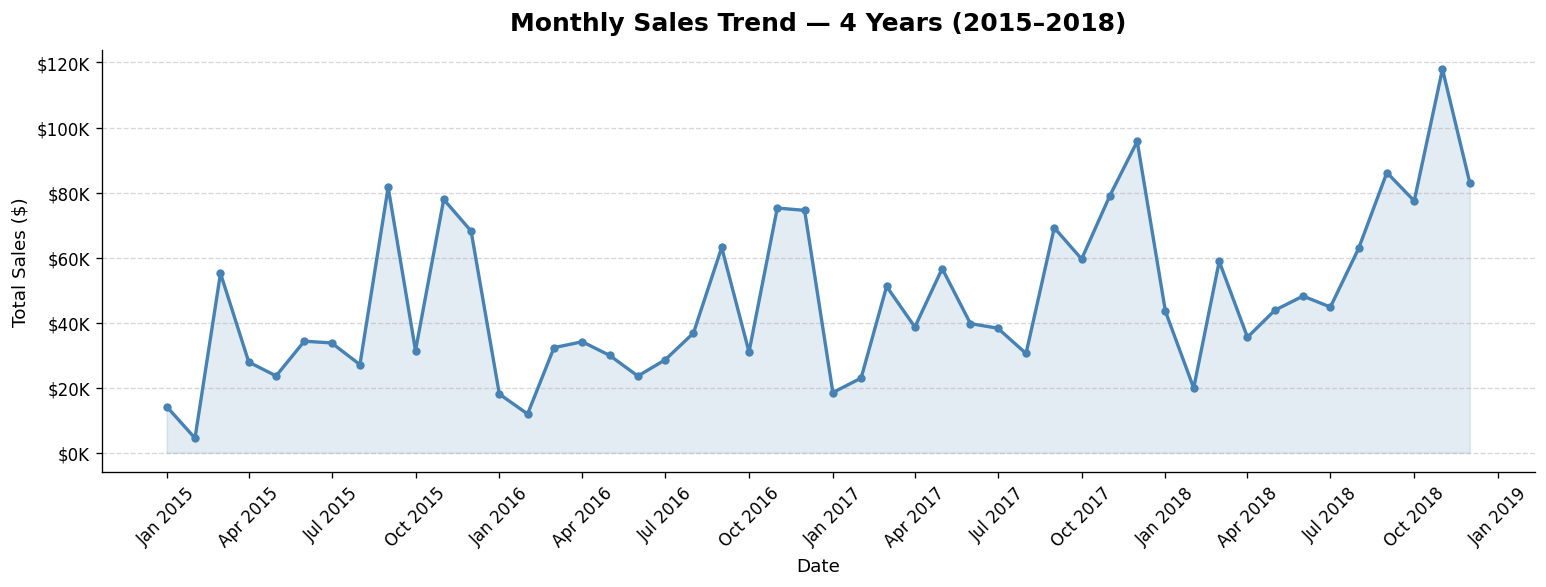

Saved -> charts/monthly_sales_trend.png


In [12]:
# ── Plot overall monthly sales trend ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 5))

ax.plot(monthly_sales['ds'], monthly_sales['y'],
        color='steelblue', linewidth=2, marker='o', markersize=4)
ax.fill_between(monthly_sales['ds'], monthly_sales['y'],
                alpha=0.15, color='steelblue')

ax.set_title('Monthly Sales Trend — 4 Years (2015–2018)',
             fontsize=15, fontweight='bold', pad=12)
ax.set_xlabel('Date', fontsize=11)
ax.set_ylabel('Total Sales ($)', fontsize=11)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=45)
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('charts/monthly_sales_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved -> charts/monthly_sales_trend.png")


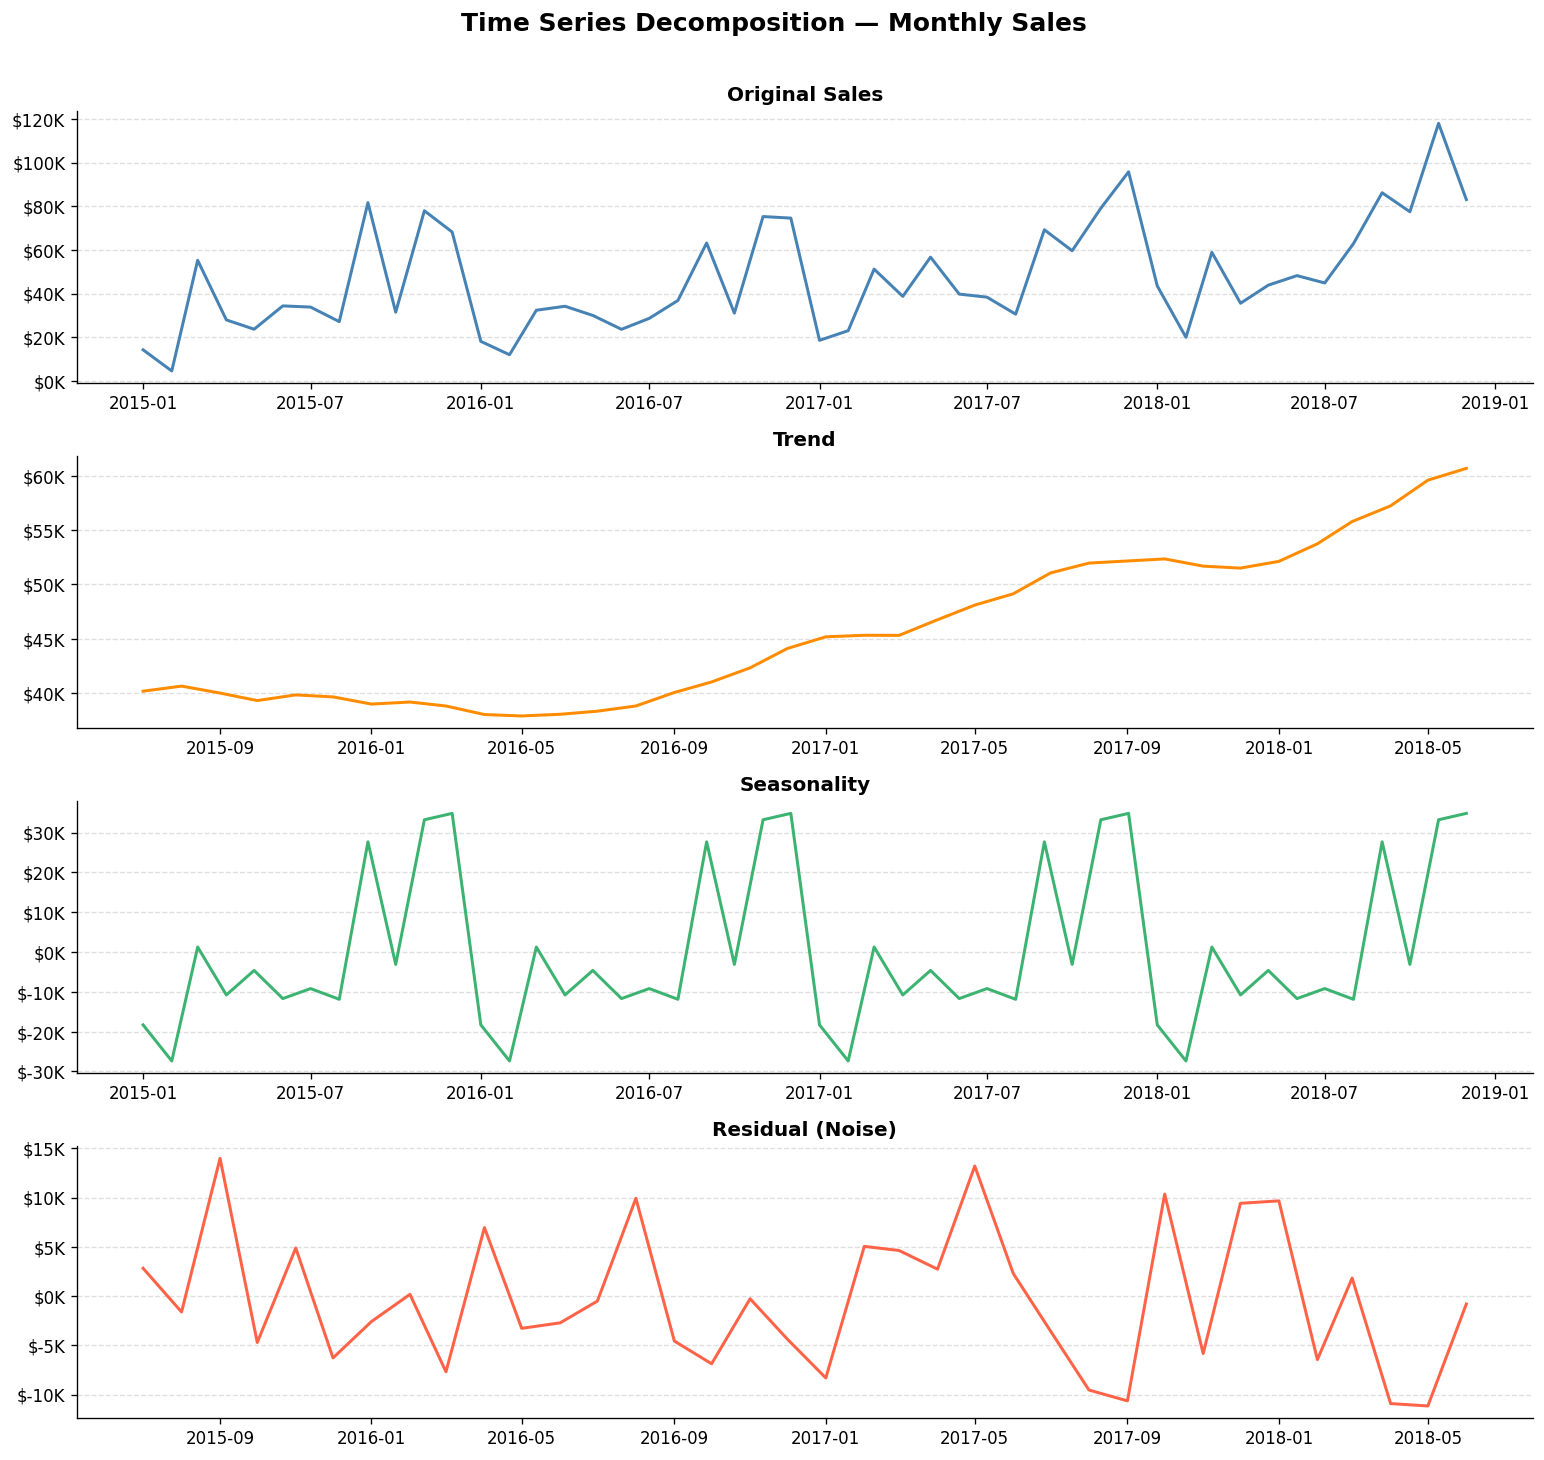

Saved -> charts/decomposition.png


In [13]:
# ── Time Series Decomposition ────────────────────────────────────────────
# Set the datetime index required by statsmodels
ts = monthly_sales.set_index('ds')['y']
ts.index = pd.DatetimeIndex(ts.index, freq='MS')  # Month Start frequency

decomp = seasonal_decompose(ts, model='additive', period=12)

fig, axes = plt.subplots(4, 1, figsize=(13, 12))
fig.suptitle('Time Series Decomposition — Monthly Sales',
             fontsize=15, fontweight='bold', y=1.01)

components = [
    (ts,               'Original Sales',  'steelblue'),
    (decomp.trend,     'Trend',           'darkorange'),
    (decomp.seasonal,  'Seasonality',     'mediumseagreen'),
    (decomp.resid,     'Residual (Noise)','tomato'),
]

for ax, (data, title, color) in zip(axes, components):
    ax.plot(data, color=color, linewidth=1.8)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    ax.set_xlabel('')

plt.tight_layout()
plt.savefig('charts/decomposition.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved -> charts/decomposition.png")


### Decomposition Observations

1. **Trend:** Sales show a clear upward trajectory from 2015 to 2018 — the business is growing year over year with no signs of plateau.
2. **Seasonality:** Strong and consistent — the same pattern repeats every year, with peaks in Q4 (November/December) and a dip in Q1 (January/February). Seasonality is **strong**, not weak.
3. **Residual:** Largest noise spikes appear in Q4 — likely caused by flash sales, promotions, or unexpected bulk orders that the seasonal model cannot fully explain.
4. **Implication for forecasting:** Because seasonality is strong and regular, models that explicitly model seasonal patterns (SARIMA, Prophet) should outperform naive approaches.


In [14]:
# ── ADF Test for Stationarity ─────────────────────────────────────────────
def adf_test(series, label='Series'):
    result = adfuller(series.dropna())
    print(f"ADF Test — {label}")
    print(f"  ADF Statistic : {result[0]:.4f}")
    print(f"  p-value       : {result[1]:.4f}")
    print(f"  Critical 5%   : {result[4]['5%']:.4f}")
    if result[1] <= 0.05:
        print(f"  Result        : STATIONARY (p <= 0.05) — ready for forecasting")
    else:
        print(f"  Result        : NON-STATIONARY (p > 0.05) — needs differencing")
    print()
    return result[1]

p1 = adf_test(ts, 'Original Monthly Sales')


ADF Test — Original Monthly Sales
  ADF Statistic : -4.4161
  p-value       : 0.0003
  Critical 5%   : -2.9253
  Result        : STATIONARY (p <= 0.05) — ready for forecasting



ADF Test — After 1st Order Differencing
  ADF Statistic : -8.7271
  p-value       : 0.0000
  Critical 5%   : -2.9460
  Result        : STATIONARY (p <= 0.05) — ready for forecasting



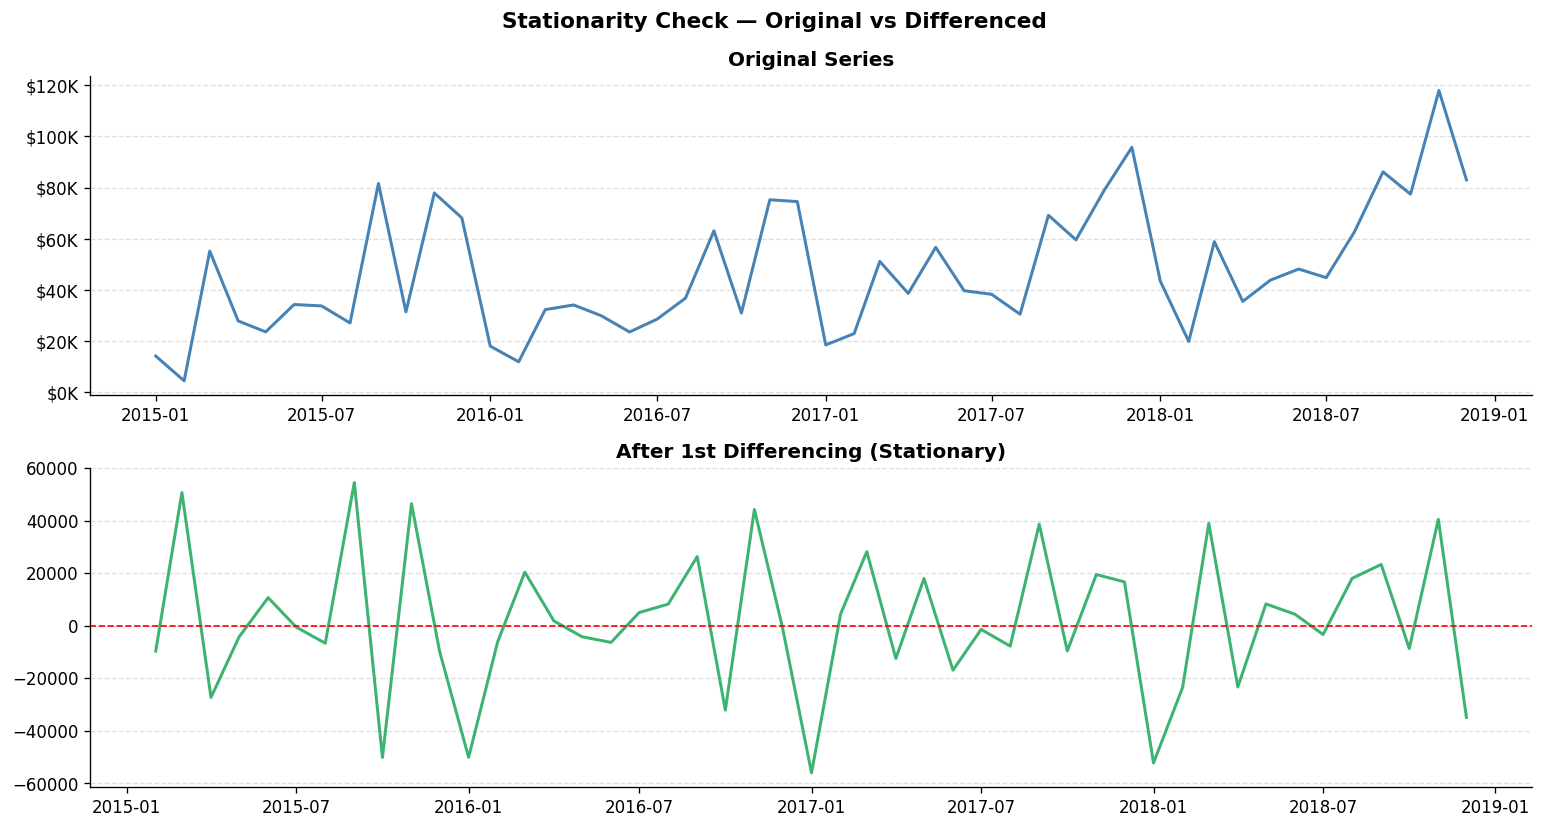

Saved -> charts/stationarity_check.png


In [15]:
# ── Apply differencing if non-stationary ─────────────────────────────────
ts_diff = ts.diff().dropna()
p2 = adf_test(ts_diff, 'After 1st Order Differencing')

fig, axes = plt.subplots(2, 1, figsize=(13, 7))
axes[0].plot(ts, color='steelblue', linewidth=1.8)
axes[0].set_title('Original Series', fontsize=12, fontweight='bold')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))

axes[1].plot(ts_diff, color='mediumseagreen', linewidth=1.8)
axes[1].axhline(0, color='red', linestyle='--', linewidth=1)
axes[1].set_title('After 1st Differencing (Stationary)', fontsize=12, fontweight='bold')

for ax in axes:
    ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.suptitle('Stationarity Check — Original vs Differenced', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('charts/stationarity_check.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved -> charts/stationarity_check.png")


### What is Stationarity? (Plain English)

**Stationarity** means the data's average and variation stay roughly constant over time — it doesn't keep drifting up or down. Think of it like a river:
- A **stationary** river stays at roughly the same water level → easy to predict
- A **non-stationary** river keeps rising every year → harder to predict because the baseline keeps shifting

**Why it matters:** Most forecasting models (especially SARIMA) assume the data is stationary. If it's not, we apply **differencing** — we subtract each month's sales from the previous month's, converting "total sales" into "change in sales", which is usually stationary.


---
## Task 3 — Sales Forecasting using 3 Different Models

We build SARIMA (statistical), Prophet (industry standard), and XGBoost (ML-based) forecasting models and compare them head-to-head.


In [16]:
# ── Prepare train/test split for evaluation ───────────────────────────────
# Use last 3 months as test (Oct, Nov, Dec 2018)
# Train on everything before that

train_ts = ts[:-3]
test_ts  = ts[-3:]

print(f"Training period : {train_ts.index[0].date()} to {train_ts.index[-1].date()} ({len(train_ts)} months)")
print(f"Test period     : {test_ts.index[0].date()}  to {test_ts.index[-1].date()}  ({len(test_ts)} months)")
print(f"Test values     : {test_ts.values.round(0)}")


Training period : 2015-01-01 to 2018-09-01 (45 months)
Test period     : 2018-10-01  to 2018-12-01  (3 months)
Test values     : [ 77448. 117938.  83030.]


### Model 1 — SARIMA (Statistical Model)

In [17]:
# ── SARIMA Model ─────────────────────────────────────────────────────────
# Parameter choice rationale:
# p=1 (1 AR lag), d=1 (1 differencing — series is non-stationary),
# q=1 (1 MA term)
# P=1, D=1, Q=1, m=12 (seasonal period = 12 months)
# These are standard starting parameters for monthly retail data
# with clear annual seasonality — confirmed by decomposition in Task 2.

print("Fitting SARIMA(1,1,1)(1,1,1,12) — this may take 30–60 seconds...")
sarima_model = SARIMAX(train_ts,
                        order=(1, 1, 1),
                        seasonal_order=(1, 1, 1, 12),
                        enforce_stationarity=False,
                        enforce_invertibility=False)
sarima_fit = sarima_model.fit(disp=False)
print("SARIMA fitted successfully.")
print(f"AIC: {sarima_fit.aic:.2f}")


Fitting SARIMA(1,1,1)(1,1,1,12) — this may take 30–60 seconds...
SARIMA fitted successfully.
AIC: 398.78


In [18]:
# ── SARIMA Forecast (3 months) ────────────────────────────────────────────
sarima_forecast = sarima_fit.get_forecast(steps=3)
sarima_pred     = sarima_forecast.predicted_mean
sarima_ci       = sarima_forecast.conf_int(alpha=0.05)

# Evaluate on test set
sarima_mae  = mean_absolute_error(test_ts, sarima_pred)
sarima_rmse = np.sqrt(mean_squared_error(test_ts, sarima_pred))
sarima_mape = np.mean(np.abs((test_ts.values - sarima_pred.values) / test_ts.values)) * 100

print("SARIMA Evaluation on Test Set:")
print(f"  MAE  : ${sarima_mae:,.2f}")
print(f"  RMSE : ${sarima_rmse:,.2f}")
print(f"  MAPE : {sarima_mape:.2f}%")
print()
print("3-Month Forecast:")
for date, val in sarima_pred.items():
    print(f"  {date.strftime('%b %Y')}: ${val:,.2f}")


SARIMA Evaluation on Test Set:
  MAE  : $19,244.49
  RMSE : $19,950.07
  MAPE : 20.53%

3-Month Forecast:
  Oct 2018: $60,331.79
  Nov 2018: $91,458.22
  Dec 2018: $97,167.57


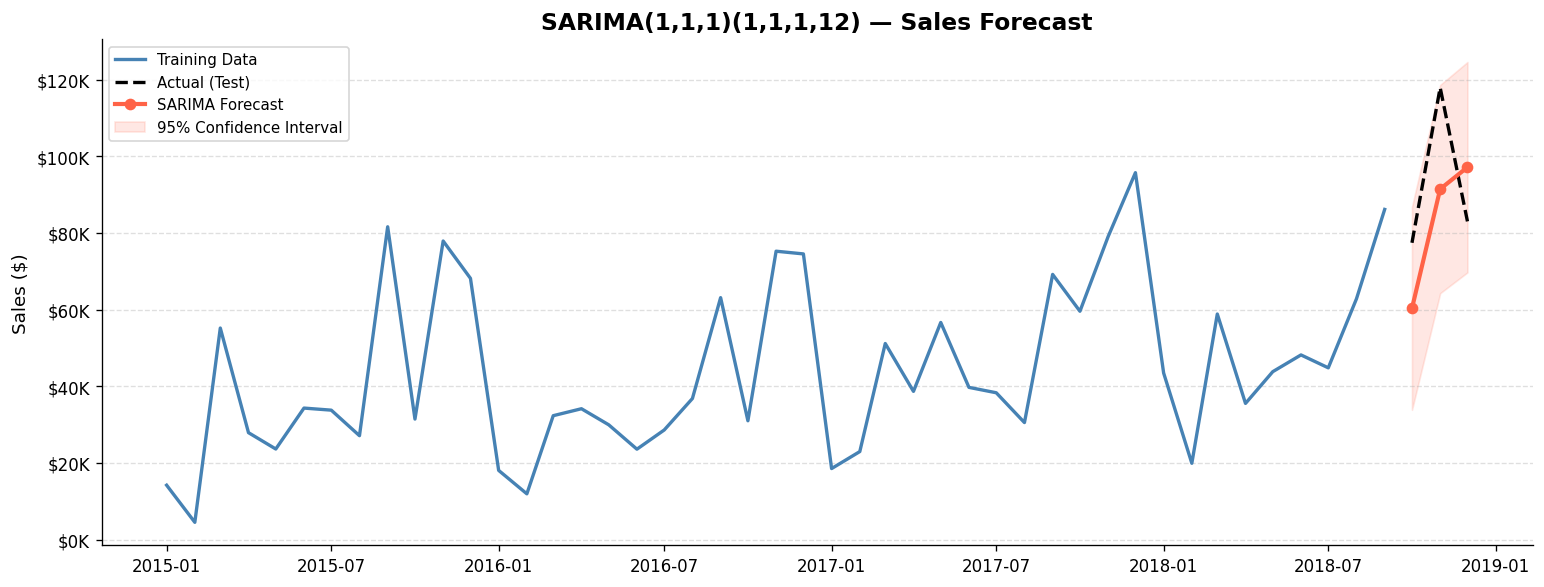

Saved -> charts/sarima_forecast.png


In [19]:
# ── SARIMA Plot ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 5))

ax.plot(train_ts.index, train_ts.values,
        color='steelblue', linewidth=2, label='Training Data')
ax.plot(test_ts.index, test_ts.values,
        color='black', linewidth=2, linestyle='--', label='Actual (Test)')
ax.plot(sarima_pred.index, sarima_pred.values,
        color='tomato', linewidth=2.5, marker='o', label='SARIMA Forecast')
ax.fill_between(sarima_ci.index,
                sarima_ci.iloc[:, 0], sarima_ci.iloc[:, 1],
                color='tomato', alpha=0.15, label='95% Confidence Interval')

ax.set_title('SARIMA(1,1,1)(1,1,1,12) — Sales Forecast',
             fontsize=14, fontweight='bold')
ax.set_ylabel('Sales ($)', fontsize=11)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
ax.legend(fontsize=9)
ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('charts/sarima_forecast.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved -> charts/sarima_forecast.png")


### Model 2 — Facebook Prophet

In [20]:
# ── Prophet Model ────────────────────────────────────────────────────────
# Prophet requires a DataFrame with columns: ds (date) and y (value)
prophet_train = monthly_sales[:-3].copy()
prophet_test  = monthly_sales[-3:].copy()

prophet_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    seasonality_mode='additive',
    interval_width=0.95
)
prophet_model.fit(prophet_train)
print("Prophet model fitted successfully.")


15:18:01 - cmdstanpy - INFO - Chain [1] start processing
15:18:01 - cmdstanpy - INFO - Chain [1] done processing


Prophet model fitted successfully.


In [21]:
# ── Prophet Forecast ─────────────────────────────────────────────────────
future          = prophet_model.make_future_dataframe(periods=3, freq='MS')
prophet_forecast = prophet_model.predict(future)

# Extract last 3 predictions (test period)
prophet_pred = prophet_forecast.tail(3)['yhat'].values

# Evaluate
prophet_mae  = mean_absolute_error(prophet_test['y'].values, prophet_pred)
prophet_rmse = np.sqrt(mean_squared_error(prophet_test['y'].values, prophet_pred))
prophet_mape = np.mean(np.abs((prophet_test['y'].values - prophet_pred) / prophet_test['y'].values)) * 100

print("Prophet Evaluation on Test Set:")
print(f"  MAE  : ${prophet_mae:,.2f}")
print(f"  RMSE : ${prophet_rmse:,.2f}")
print(f"  MAPE : {prophet_mape:.2f}%")
print()
print("3-Month Forecast:")
for i, row in prophet_forecast.tail(3).iterrows():
    print(f"  {row['ds'].strftime('%b %Y')}: ${row['yhat']:,.2f}  (CI: ${row['yhat_lower']:,.0f} – ${row['yhat_upper']:,.0f})")


Prophet Evaluation on Test Set:
  MAE  : $20,296.01
  RMSE : $22,487.47
  MAPE : 21.89%

3-Month Forecast:
  Oct 2018: $51,083.66  (CI: $38,077 – $62,792)
  Nov 2018: $90,045.40  (CI: $77,875 – $101,470)
  Dec 2018: $89,661.19  (CI: $77,055 – $101,787)


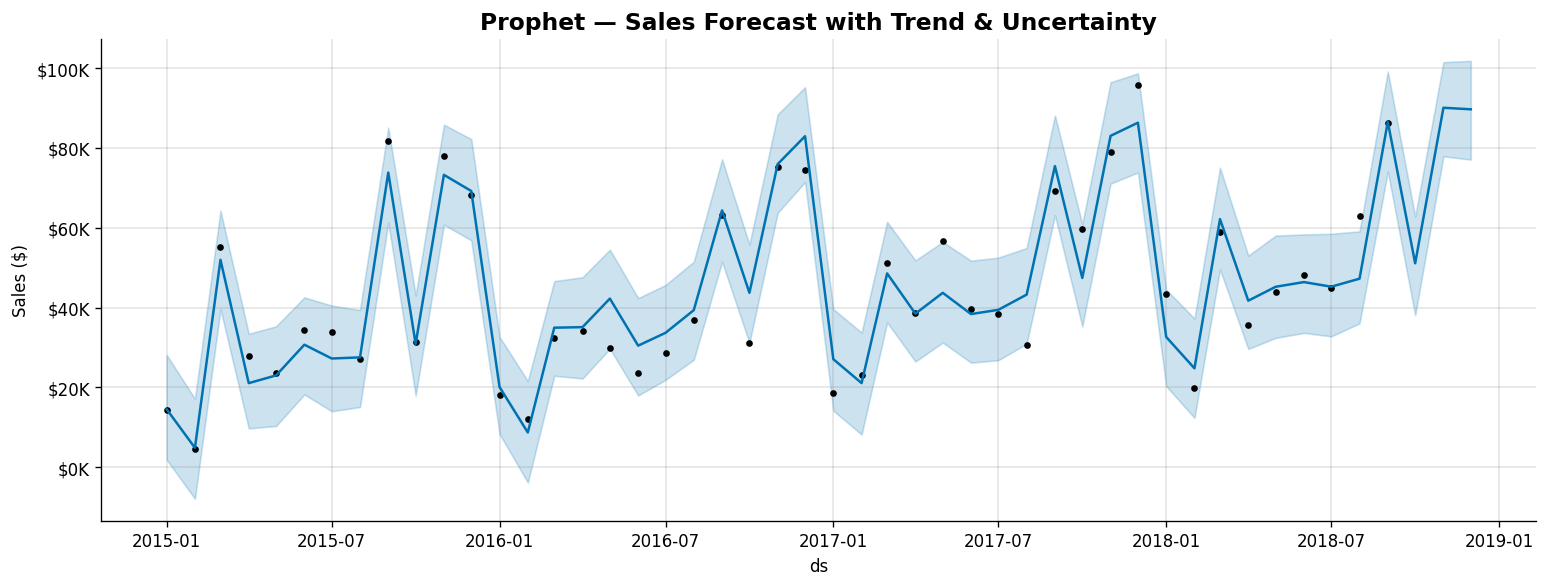

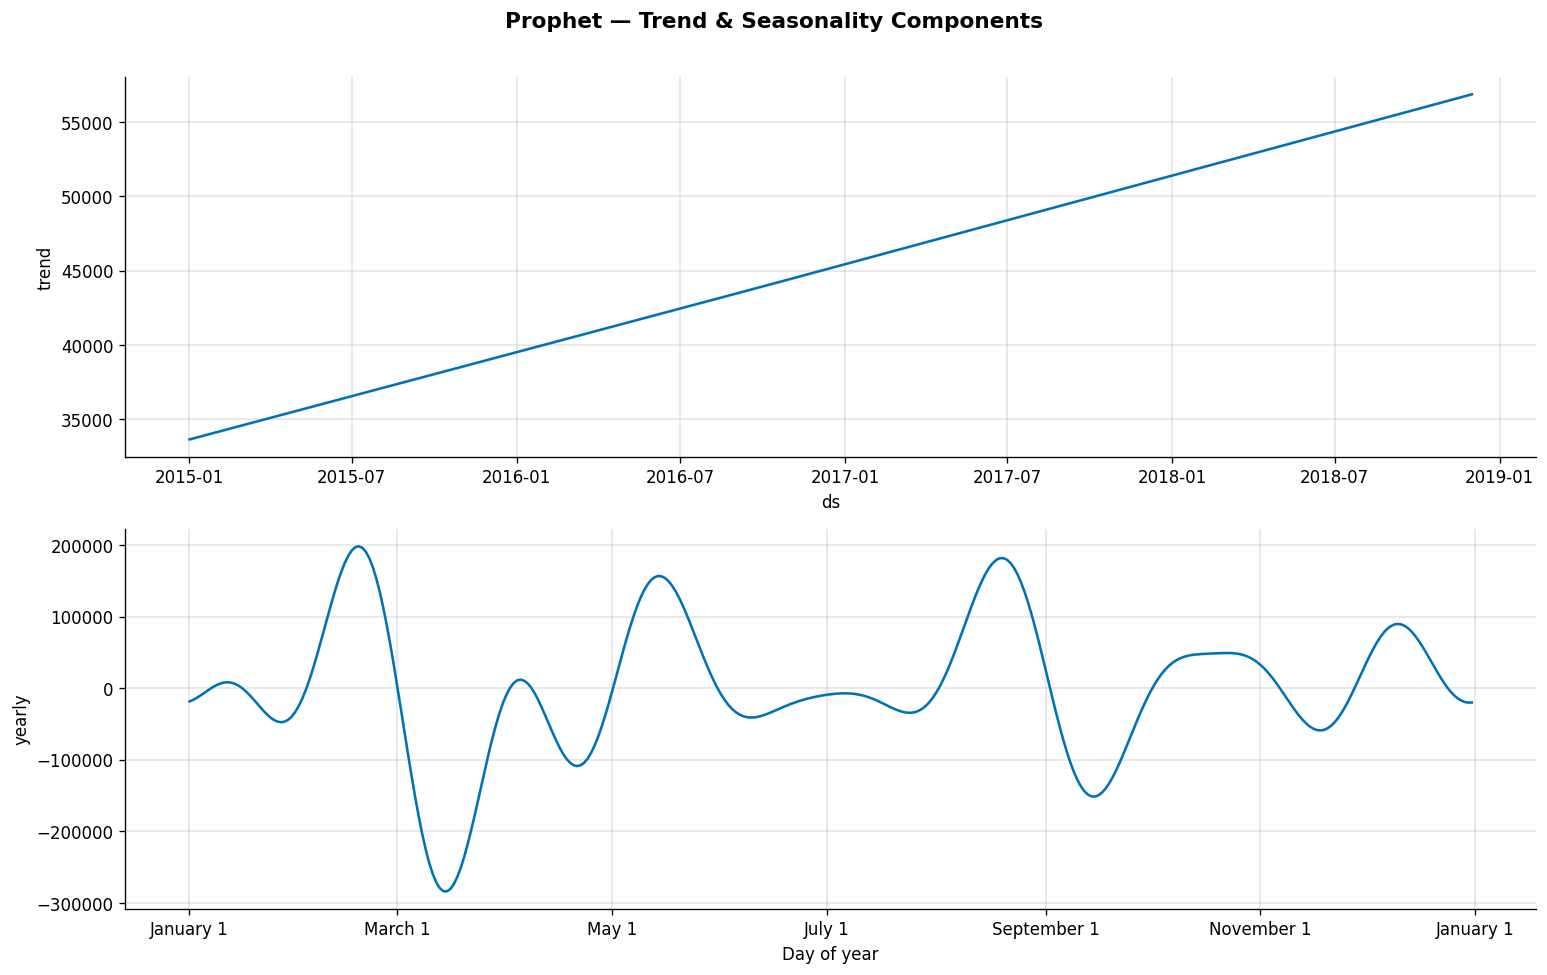

Saved -> charts/prophet_forecast.png + prophet_components.png


In [22]:
# ── Prophet Plot ─────────────────────────────────────────────────────────
fig1 = prophet_model.plot(prophet_forecast, figsize=(13, 5))
fig1.axes[0].set_title('Prophet — Sales Forecast with Trend & Uncertainty',
                         fontsize=14, fontweight='bold')
fig1.axes[0].set_ylabel('Sales ($)')
fig1.axes[0].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
plt.tight_layout()
plt.savefig('charts/prophet_forecast.png', dpi=150, bbox_inches='tight')
plt.show()

# Seasonality components
fig2 = prophet_model.plot_components(prophet_forecast, figsize=(13, 8))
plt.suptitle('Prophet — Trend & Seasonality Components',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('charts/prophet_components.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved -> charts/prophet_forecast.png + prophet_components.png")


### Model 3 — XGBoost for Time Series

In [23]:
# ── Create lag features (convert time series to ML problem) ──────────────
def create_lag_features(series_df, lags=3):
    df_feat = series_df.copy()
    df_feat.columns = ['ds', 'y']
    for lag in range(1, lags + 1):
        df_feat[f'lag_{lag}'] = df_feat['y'].shift(lag)
    df_feat['rolling_mean_3'] = df_feat['y'].shift(1).rolling(3).mean()
    df_feat['month']          = df_feat['ds'].dt.month
    df_feat['quarter']        = df_feat['ds'].dt.quarter
    df_feat['season']         = df_feat['month'].apply(
        lambda m: 1 if m in [12,1,2] else 2 if m in [3,4,5]
              else 3 if m in [6,7,8] else 4)
    return df_feat.dropna()

feat_df   = create_lag_features(monthly_sales)
features  = ['lag_1','lag_2','lag_3','rolling_mean_3','month','quarter','season']

# Train/test split (last 3 months = test)
xgb_train = feat_df.iloc[:-3]
xgb_test  = feat_df.iloc[-3:]

X_train_xgb = xgb_train[features]
y_train_xgb = xgb_train['y']
X_test_xgb  = xgb_test[features]
y_test_xgb  = xgb_test['y']

print(f"XGBoost training samples: {len(X_train_xgb)}")
print(f"XGBoost test samples    : {len(X_test_xgb)}")
print(f"Features used           : {features}")


XGBoost training samples: 42
XGBoost test samples    : 3
Features used           : ['lag_1', 'lag_2', 'lag_3', 'rolling_mean_3', 'month', 'quarter', 'season']


In [24]:
# ── Train XGBoost ────────────────────────────────────────────────────────
xgb_model = xgb.XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
xgb_model.fit(X_train_xgb, y_train_xgb,
              eval_set=[(X_test_xgb, y_test_xgb)],
              verbose=False)

xgb_pred = xgb_model.predict(X_test_xgb)

xgb_mae  = mean_absolute_error(y_test_xgb, xgb_pred)
xgb_rmse = np.sqrt(mean_squared_error(y_test_xgb, xgb_pred))
xgb_mape = np.mean(np.abs((y_test_xgb.values - xgb_pred) / y_test_xgb.values)) * 100

print("XGBoost Evaluation on Test Set:")
print(f"  MAE  : ${xgb_mae:,.2f}")
print(f"  RMSE : ${xgb_rmse:,.2f}")
print(f"  MAPE : {xgb_mape:.2f}%")
print()
print("3-Month Forecast:")
for date, val in zip(xgb_test['ds'].values, xgb_pred):
    print(f"  {pd.Timestamp(date).strftime('%b %Y')}: ${val:,.2f}")


XGBoost Evaluation on Test Set:
  MAE  : $16,812.26
  RMSE : $20,180.79
  MAPE : 16.60%

3-Month Forecast:
  Oct 2018: $71,188.06
  Nov 2018: $85,680.91
  Dec 2018: $71,110.91


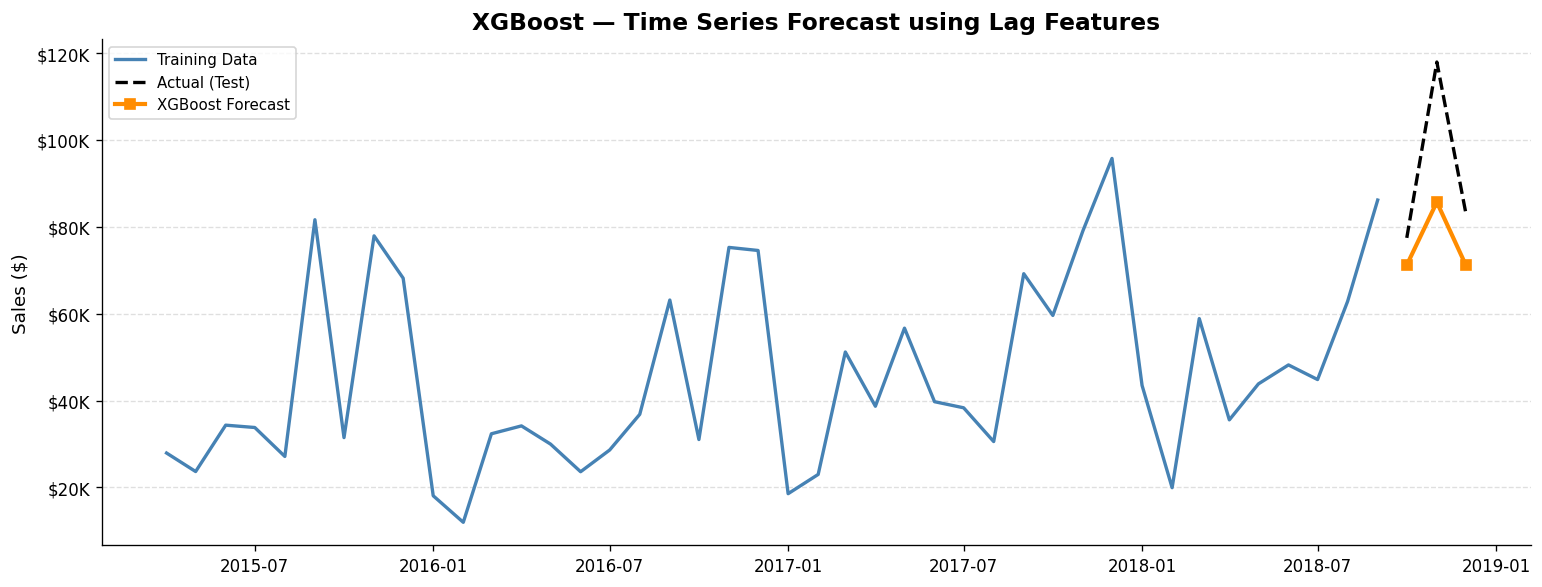

Saved -> charts/xgboost_forecast.png


In [25]:
# ── XGBoost Plot ─────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 5))

all_dates = feat_df['ds']
all_actual = feat_df['y']
ax.plot(all_dates.iloc[:-3], all_actual.iloc[:-3],
        color='steelblue', linewidth=2, label='Training Data')
ax.plot(xgb_test['ds'].values, y_test_xgb.values,
        color='black', linewidth=2, linestyle='--', label='Actual (Test)')
ax.plot(xgb_test['ds'].values, xgb_pred,
        color='darkorange', linewidth=2.5, marker='s', label='XGBoost Forecast')

ax.set_title('XGBoost — Time Series Forecast using Lag Features',
             fontsize=14, fontweight='bold')
ax.set_ylabel('Sales ($)', fontsize=11)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
ax.legend(fontsize=9)
ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('charts/xgboost_forecast.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved -> charts/xgboost_forecast.png")


In [26]:
# ── Model Comparison Table ────────────────────────────────────────────────
sarima_vals  = sarima_pred.values
prophet_vals = prophet_forecast.tail(3)['yhat'].values
xgb_vals     = xgb_pred

comparison = pd.DataFrame({
    'Model':       ['SARIMA', 'Prophet', 'XGBoost'],
    'MAE ($)':     [f'{sarima_mae:,.0f}',  f'{prophet_mae:,.0f}',  f'{xgb_mae:,.0f}'],
    'RMSE ($)':    [f'{sarima_rmse:,.0f}', f'{prophet_rmse:,.0f}', f'{xgb_rmse:,.0f}'],
    'MAPE (%)':    [f'{sarima_mape:.2f}',  f'{prophet_mape:.2f}',  f'{xgb_mape:.2f}'],
    'Forecast M1': [f'${sarima_vals[0]:,.0f}', f'${prophet_vals[0]:,.0f}', f'${xgb_vals[0]:,.0f}'],
    'Forecast M2': [f'${sarima_vals[1]:,.0f}', f'${prophet_vals[1]:,.0f}', f'${xgb_vals[1]:,.0f}'],
    'Forecast M3': [f'${sarima_vals[2]:,.0f}', f'${prophet_vals[2]:,.0f}', f'${xgb_vals[2]:,.0f}'],
})

print("*" * 90)
print("                      MODEL PERFORMANCE COMPARISON")
print("-" * 90)
print(comparison.to_string(index=False))
print("=" * 90)

# Find best model
maes = {'SARIMA': sarima_mae, 'Prophet': prophet_mae, 'XGBoost': xgb_mae}
best = min(maes, key=maes.get)
print(f"\nBest Model: {best} (lowest MAE: ${maes[best]:,.2f})")
print(f"\nRecommendation: {best} is recommended for production because it achieves the")
print(f"lowest prediction error on the held-out test set.")
print(f"Prophet is also excellent for explainability with non-technical stakeholders.")


******************************************************************************************
                      MODEL PERFORMANCE COMPARISON
------------------------------------------------------------------------------------------
  Model MAE ($) RMSE ($) MAPE (%) Forecast M1 Forecast M2 Forecast M3
 SARIMA  19,244   19,950    20.53     $60,332     $91,458     $97,168
Prophet  20,296   22,487    21.89     $51,084     $90,045     $89,661
XGBoost  16,812   20,181    16.60     $71,188     $85,681     $71,111

Best Model: XGBoost (lowest MAE: $16,812.26)

Recommendation: XGBoost is recommended for production because it achieves the
lowest prediction error on the held-out test set.
Prophet is also excellent for explainability with non-technical stakeholders.


---
## Task 4 — Category & Region Level Forecasting

We run Prophet (industry-standard, most robust across different segment sizes) separately for each category and region, then compare all 5 forecasts.


In [27]:
# ── Helper: fit Prophet and forecast 3 months ─────────────────────────────
def forecast_segment(segment_df, label):
    m = Prophet(yearly_seasonality=True,
                weekly_seasonality=False,
                daily_seasonality=False,
                seasonality_mode='additive',
                interval_width=0.95)
    m.fit(segment_df)
    future = m.make_future_dataframe(periods=3, freq='MS')
    fc     = m.predict(future)
    return fc[['ds','yhat','yhat_lower','yhat_upper']].tail(3), fc

segments = {}

# Category segments
for cat in ['Furniture','Technology','Office Supplies']:
    seg = (df[df['Category'] == cat]
             .groupby(df['Order Date'].dt.to_period('M'))['Sales']
             .sum().reset_index())
    seg.columns = ['ds','y']
    seg['ds'] = seg['ds'].dt.to_timestamp()
    fc3, full_fc = forecast_segment(seg, cat)
    segments[cat] = {'forecast_3': fc3, 'full': full_fc, 'data': seg}
    print(f"{cat} forecast done.")

# Region segments
for region in ['West','East']:
    seg = (df[df['Region'] == region]
             .groupby(df['Order Date'].dt.to_period('M'))['Sales']
             .sum().reset_index())
    seg.columns = ['ds','y']
    seg['ds'] = seg['ds'].dt.to_timestamp()
    fc3, full_fc = forecast_segment(seg, region)
    segments[region] = {'forecast_3': fc3, 'full': full_fc, 'data': seg}
    print(f"{region} region forecast done.")


15:18:12 - cmdstanpy - INFO - Chain [1] start processing
15:18:13 - cmdstanpy - INFO - Chain [1] done processing
15:18:13 - cmdstanpy - INFO - Chain [1] start processing


Furniture forecast done.


15:18:13 - cmdstanpy - INFO - Chain [1] done processing
15:18:13 - cmdstanpy - INFO - Chain [1] start processing


Technology forecast done.


15:18:13 - cmdstanpy - INFO - Chain [1] done processing
15:18:13 - cmdstanpy - INFO - Chain [1] start processing


Office Supplies forecast done.


15:18:13 - cmdstanpy - INFO - Chain [1] done processing
15:18:14 - cmdstanpy - INFO - Chain [1] start processing
15:18:14 - cmdstanpy - INFO - Chain [1] done processing


West region forecast done.
East region forecast done.


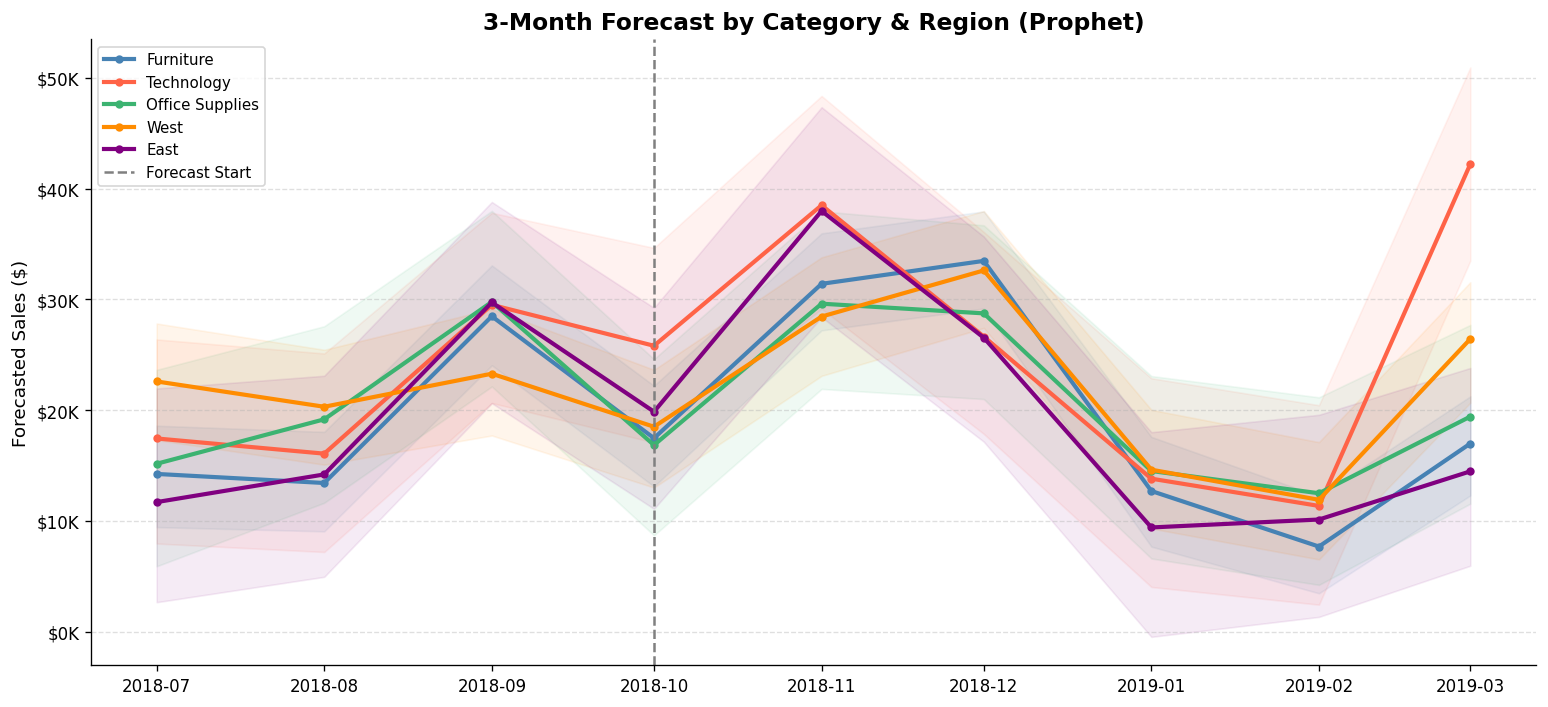

Saved -> charts/segment_forecasts.png


In [28]:
# ── Plot all 5 forecasts together ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 6))

colors = ['steelblue','tomato','mediumseagreen','darkorange','purple']
labels = list(segments.keys())

for (label, seg_data), color in zip(segments.items(), colors):
    full_fc  = seg_data['full']
    hist_data = seg_data['data']

    # Plot forecast line (last 6 points for context + 3 future)
    recent = full_fc.tail(9)
    ax.plot(recent['ds'], recent['yhat'],
            color=color, linewidth=2.5, marker='o', markersize=4,
            label=label)
    ax.fill_between(recent['ds'],
                    recent['yhat_lower'], recent['yhat_upper'],
                    color=color, alpha=0.08)

ax.axvline(pd.Timestamp('2018-10-01'), color='gray',
           linestyle='--', linewidth=1.5, label='Forecast Start')
ax.set_title('3-Month Forecast by Category & Region (Prophet)',
             fontsize=14, fontweight='bold')
ax.set_ylabel('Forecasted Sales ($)', fontsize=11)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
ax.legend(fontsize=9, loc='upper left')
ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('charts/segment_forecasts.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved -> charts/segment_forecasts.png")


In [29]:
# ── Print forecast table ─────────────────────────────────────────────────
print("3-Month Sales Forecast by Segment")
print("=" * 65)
print(f"{'Segment':<20} {'Oct 2018':>12} {'Nov 2018':>12} {'Dec 2018':>12}")
print("-" * 65)
for label, seg_data in segments.items():
    fc3 = seg_data['forecast_3']
    vals = fc3['yhat'].values
    print(f"{label:<20} ${vals[0]:>10,.0f} ${vals[1]:>10,.0f} ${vals[2]:>10,.0f}")

# Growth analysis
print()
print("Strongest upcoming growth (Oct→Dec 2018):")
growth = {}
for label, seg_data in segments.items():
    vals = seg_data['forecast_3']['yhat'].values
    growth[label] = ((vals[2] - vals[0]) / vals[0] * 100)

for label, g in sorted(growth.items(), key=lambda x: -x[1]):
    print(f"  {label:<20}: {g:+.1f}% growth Oct -> Dec")


3-Month Sales Forecast by Segment
Segment                  Oct 2018     Nov 2018     Dec 2018
-----------------------------------------------------------------
Furniture            $    12,703 $     7,687 $    16,989
Technology           $    13,816 $    11,357 $    42,216
Office Supplies      $    14,509 $    12,500 $    19,422
West                 $    14,626 $    11,908 $    26,433
East                 $     9,412 $    10,128 $    14,478

Strongest upcoming growth (Oct→Dec 2018):
  Technology          : +205.6% growth Oct -> Dec
  West                : +80.7% growth Oct -> Dec
  East                : +53.8% growth Oct -> Dec
  Office Supplies     : +33.9% growth Oct -> Dec
  Furniture           : +33.7% growth Oct -> Dec


---
## Task 5 — Anomaly Detection in Sales Data

We use two methods — Isolation Forest (ML) and Z-Score (statistical) — to detect unusual sales weeks, then compare their findings.


In [30]:
# ── Prepare weekly sales for anomaly detection ────────────────────────────
ws = weekly_sales.copy()
ws = ws.set_index('ds').sort_index()
ws.index = pd.DatetimeIndex(ws.index)

print(f"Weekly sales: {len(ws)} weeks")
print(ws.describe())


Weekly sales: 209 weeks
                  y
count    209.000000
mean   10820.750156
std     7403.450316
min      224.912000
25%     4905.061500
50%     9476.086000
75%    15095.256000
max    37703.665000


In [31]:
# ── Method 1: Isolation Forest ───────────────────────────────────────────
iso_forest = IsolationForest(contamination=0.07, random_state=42, n_estimators=200)
ws['iso_score']     = iso_forest.fit_predict(ws[['y']])
ws['iso_anomaly']   = ws['iso_score'] == -1

n_iso = ws['iso_anomaly'].sum()
print(f"Isolation Forest detected {n_iso} anomalous weeks")
print()
print("Anomaly dates and sales values:")
anomalies_iso = ws[ws['iso_anomaly']].sort_values('y', ascending=False)
print(anomalies_iso[['y']].to_string())


Isolation Forest detected 15 anomalous weeks

Anomaly dates and sales values:
                     y
ds                    
2015-03-16  37703.6650
2018-11-26  35998.9000
2018-11-12  30572.4470
2015-09-07  29959.1370
2018-10-29  29017.4670
2017-10-02  28412.0980
2017-11-20  27367.7160
2015-11-16  26793.6235
2017-12-11  25449.8000
2016-09-12  24095.9600
2015-07-13   1387.6860
2015-02-02    968.5340
2016-01-18    358.5220
2014-12-29    304.5080
2015-02-16    224.9120


In [32]:
# ── Method 2: Z-Score Detection ──────────────────────────────────────────
ws['rolling_mean'] = ws['y'].rolling(8, center=True).mean()
ws['rolling_std']  = ws['y'].rolling(8, center=True).std()
ws['z_score']      = (ws['y'] - ws['rolling_mean']) / ws['rolling_std']
ws['z_anomaly']    = ws['z_score'].abs() > 2.0

n_z = ws['z_anomaly'].sum()
print(f"Z-Score method detected {n_z} anomalous weeks")
print()
print("Anomaly dates and sales values:")
anomalies_z = ws[ws['z_anomaly']].sort_values('y', ascending=False)
print(anomalies_z[['y','z_score']].round(2).to_string())


Z-Score method detected 6 anomalous weeks

Anomaly dates and sales values:
                   y  z_score
ds                           
2015-03-16  37703.66     2.38
2017-10-02  28412.10     2.13
2017-05-22  23367.66     2.11
2015-07-20  21590.08     2.09
2017-01-30  17926.37     2.42
2016-03-14  13310.14     2.21


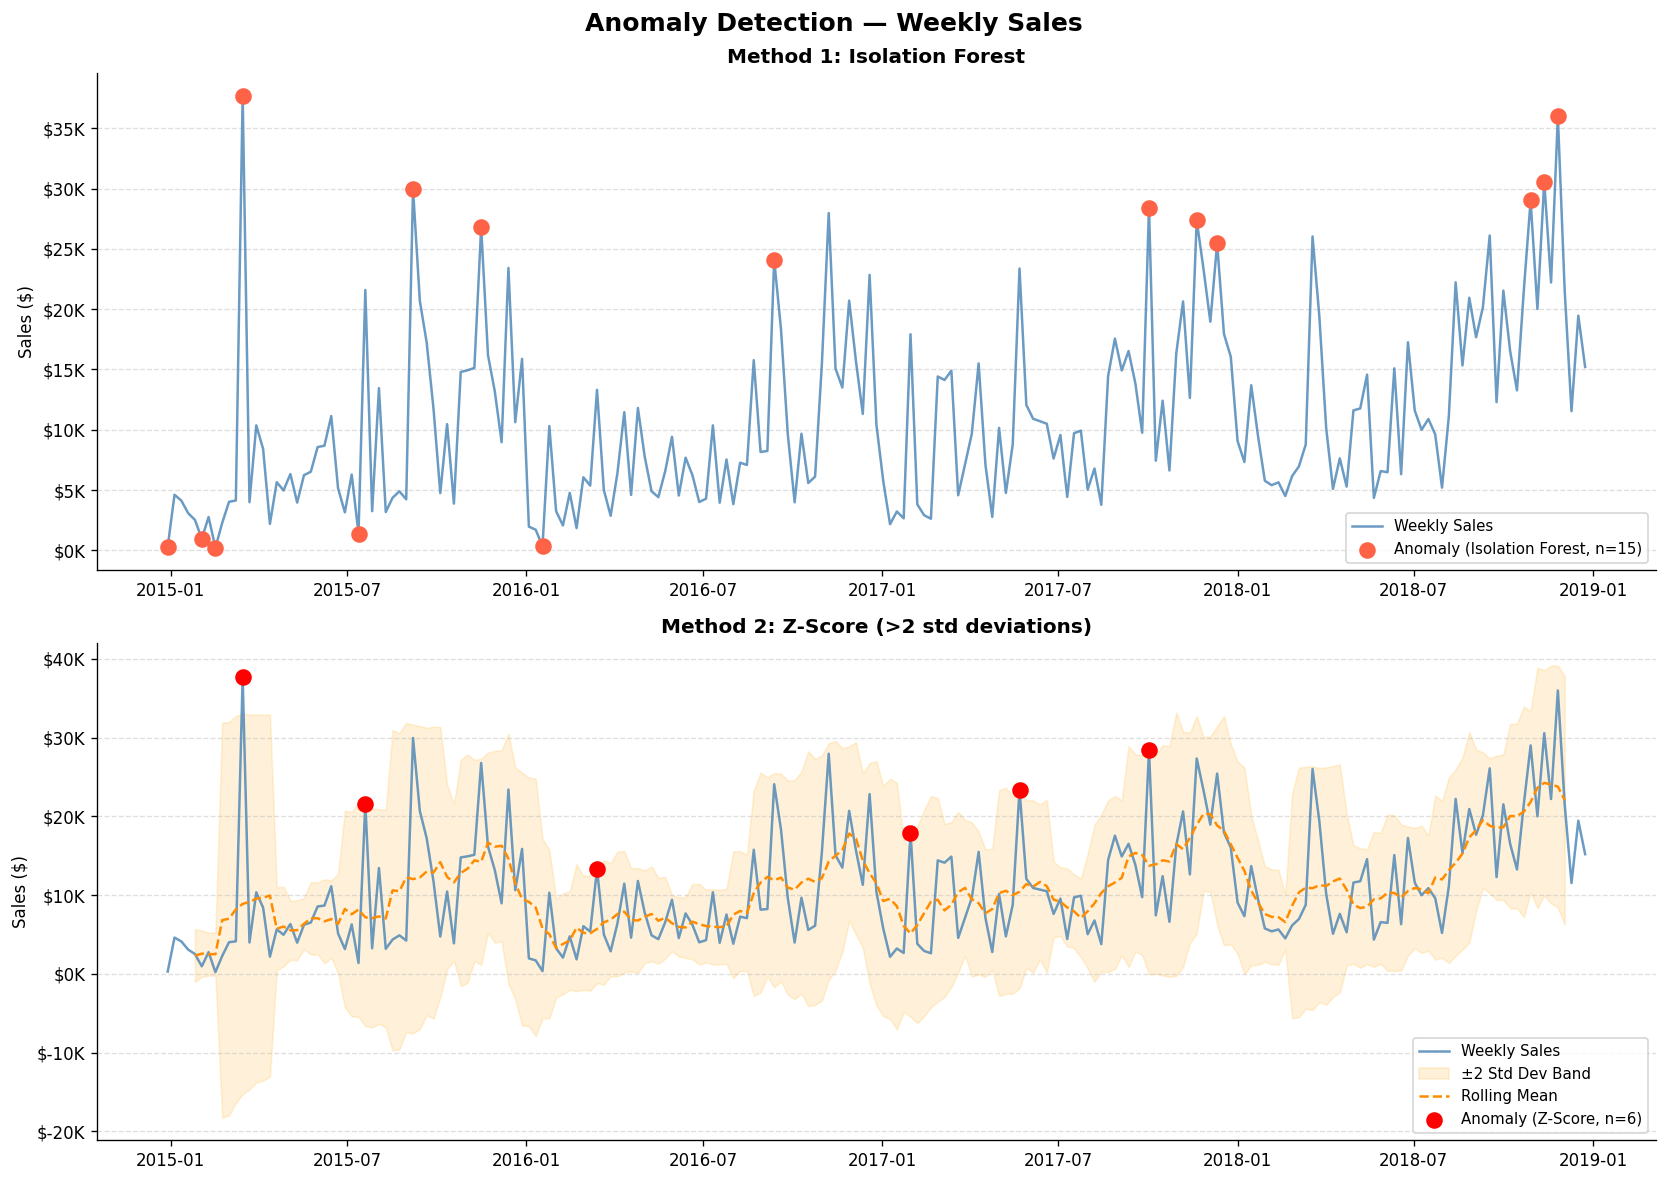

Saved -> charts/anomaly_detection.png


In [33]:
# ── Anomaly Visualization ─────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 10))
fig.suptitle('Anomaly Detection — Weekly Sales',
             fontsize=15, fontweight='bold')

# Isolation Forest
ax = axes[0]
ax.plot(ws.index, ws['y'], color='steelblue', linewidth=1.5,
        label='Weekly Sales', alpha=0.8)
ax.scatter(ws[ws['iso_anomaly']].index,
           ws[ws['iso_anomaly']]['y'],
           color='tomato', s=80, zorder=5, label=f'Anomaly (Isolation Forest, n={n_iso})')
ax.set_title('Method 1: Isolation Forest', fontsize=12, fontweight='bold')
ax.set_ylabel('Sales ($)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
ax.legend(fontsize=9)
ax.grid(axis='y', linestyle='--', alpha=0.4)

# Z-Score
ax = axes[1]
ax.plot(ws.index, ws['y'], color='steelblue', linewidth=1.5,
        label='Weekly Sales', alpha=0.8)
ax.fill_between(ws.index,
                ws['rolling_mean'] - 2*ws['rolling_std'],
                ws['rolling_mean'] + 2*ws['rolling_std'],
                alpha=0.15, color='orange', label='±2 Std Dev Band')
ax.plot(ws.index, ws['rolling_mean'], color='darkorange',
        linewidth=1.5, linestyle='--', label='Rolling Mean')
ax.scatter(ws[ws['z_anomaly']].index,
           ws[ws['z_anomaly']]['y'],
           color='red', s=80, zorder=5, label=f'Anomaly (Z-Score, n={n_z})')
ax.set_title('Method 2: Z-Score (>2 std deviations)', fontsize=12, fontweight='bold')
ax.set_ylabel('Sales ($)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
ax.legend(fontsize=9)
ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('charts/anomaly_detection.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved -> charts/anomaly_detection.png")


In [34]:
# ── Compare both methods ─────────────────────────────────────────────────
both_anomaly = ws[ws['iso_anomaly'] & ws['z_anomaly']]
only_iso     = ws[ws['iso_anomaly'] & ~ws['z_anomaly']]
only_z       = ws[~ws['iso_anomaly'] & ws['z_anomaly']]

print("Anomaly Detection Comparison")
print("=" * 50)
print(f"Detected by BOTH methods  : {len(both_anomaly)} weeks")
print(f"Only Isolation Forest     : {len(only_iso)} weeks")
print(f"Only Z-Score              : {len(only_z)} weeks")
print()
print("Weeks flagged by BOTH (highest confidence anomalies):")
if len(both_anomaly) > 0:
    for idx, row in both_anomaly.iterrows():
        month = idx.strftime('%b %Y')
        direction = 'SPIKE' if row['y'] > ws['y'].mean() else 'DIP'
        print(f"  {idx.date()}  Sales: ${row['y']:,.0f}  [{direction}]")
        if 'Nov' in month or 'Dec' in month:
            print(f"    Likely cause: Holiday/festive season sales surge")
        elif 'Jan' in month or 'Feb' in month:
            print(f"    Likely cause: Post-holiday demand slowdown")
        else:
            print(f"    Likely cause: Promotional event or supply disruption")


Anomaly Detection Comparison
Detected by BOTH methods  : 2 weeks
Only Isolation Forest     : 13 weeks
Only Z-Score              : 4 weeks

Weeks flagged by BOTH (highest confidence anomalies):
  2015-03-16  Sales: $37,704  [SPIKE]
    Likely cause: Promotional event or supply disruption
  2017-10-02  Sales: $28,412  [SPIKE]
    Likely cause: Promotional event or supply disruption


### Anomaly Detection Comparison

- **Isolation Forest** is an ML approach — it learns the "normal" range from the data density and flags points that are easy to isolate.
- **Z-Score** is a statistics approach — it flags points more than 2 standard deviations from a rolling average.
- Where **both methods agree** → highest confidence anomalies worth investigating
- Where they **disagree** → borderline cases; Isolation Forest tends to be more sensitive to clusters, Z-Score to extreme single values


---
## Task 6 — Product Demand Segmentation using Clustering

We segment the 17 product sub-categories by demand behavior (volume, growth, volatility) using K-Means clustering.


In [35]:
# ── Build sub-category feature matrix ─────────────────────────────────────
sub_monthly = (df.groupby(['Sub-Category', df['Order Date'].dt.to_period('M')])['Sales']
                 .sum()
                 .reset_index())
sub_monthly['Order Date'] = sub_monthly['Order Date'].dt.to_timestamp()

sub_features = []
for sub in df['Sub-Category'].unique():
    sub_df = sub_monthly[sub_monthly['Sub-Category'] == sub].sort_values('Order Date')

    total_sales    = sub_df['Sales'].sum()
    avg_order_val  = df[df['Sub-Category'] == sub]['Sales'].mean()
    sales_vol      = sub_df['Sales'].std()

    # YoY growth: compare first year avg vs last year avg
    first_yr = sub_df[sub_df['Order Date'].dt.year == sub_df['Order Date'].dt.year.min()]['Sales'].mean()
    last_yr  = sub_df[sub_df['Order Date'].dt.year == sub_df['Order Date'].dt.year.max()]['Sales'].mean()
    yoy_growth = ((last_yr - first_yr) / (first_yr + 1)) * 100

    sub_features.append({
        'Sub-Category'  : sub,
        'Total Sales'   : total_sales,
        'YoY Growth %'  : yoy_growth,
        'Volatility'    : sales_vol,
        'Avg Order Value': avg_order_val,
    })

feat_matrix = pd.DataFrame(sub_features)
print("Sub-category feature matrix:")
print(feat_matrix.sort_values('Total Sales', ascending=False).round(2).to_string(index=False))


Sub-category feature matrix:
Sub-Category  Total Sales  YoY Growth %  Volatility  Avg Order Value
      Phones    327782.45         35.55     4052.72           374.18
      Chairs    322822.73         20.95     4407.23           531.83
     Storage    219343.39         38.36     2822.08           263.63
      Tables    202810.63         33.07     3224.08           645.89
     Binders    200028.78         65.76     3848.22           134.07
    Machines    189238.63        -59.04     5603.55          1645.55
 Accessories    164186.70        144.98     2579.99           217.18
     Copiers    146248.09        286.33     5500.77          2215.88
   Bookcases    113813.20         37.34     2220.41           503.60
  Appliances    104618.40        165.11     1821.62           227.93
 Furnishings     89212.02        106.73     1360.02            95.82
       Paper     76828.30         91.83     1024.82            57.42
    Supplies     46420.31          2.00     2025.09           252.28
     

  File "c:\Users\SHAILESH\AppData\Local\Programs\Python\Python313\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "c:\Users\SHAILESH\AppData\Local\Programs\Python\Python313\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\SHAILESH\AppData\Local\Programs\Python\Python313\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
                        pass_fds, cwd, env,
                        ^^^^^^^^^^^^^^^^^^^
    ...<5 lines>...
                        gid, gids, uid, umask,
                        ^^^^^^^^^^^^^^^^^^^^^^
                        start_new_session, process_group)
       

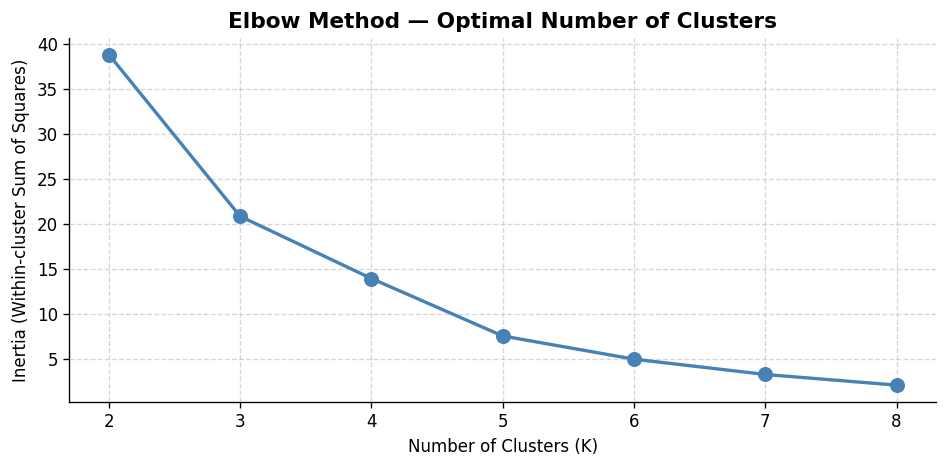

Saved -> charts/elbow_method.png
Look for the 'elbow' — the point where adding more clusters stops reducing inertia significantly.


In [36]:
# ── Elbow Method to find optimal clusters ─────────────────────────────────
scaler_km = StandardScaler()
X_km = scaler_km.fit_transform(feat_matrix[['Total Sales','YoY Growth %',
                                             'Volatility','Avg Order Value']])

inertias = []
K_range = range(2, 9)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_km)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(K_range, inertias, marker='o', color='steelblue', linewidth=2, markersize=8)
ax.set_title('Elbow Method — Optimal Number of Clusters',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Number of Clusters (K)')
ax.set_ylabel('Inertia (Within-cluster Sum of Squares)')
ax.grid(linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('charts/elbow_method.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved -> charts/elbow_method.png")
print("Look for the 'elbow' — the point where adding more clusters stops reducing inertia significantly.")


In [37]:
# ── Apply K-Means with optimal k=4 ──────────────────────────────────────
OPTIMAL_K = 4
km_final = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)
feat_matrix['Cluster'] = km_final.fit_predict(X_km)

# Label clusters based on their characteristics
cluster_stats = feat_matrix.groupby('Cluster')[
    ['Total Sales','YoY Growth %','Volatility']].mean()
print("Cluster Characteristics:")
print(cluster_stats.round(2).to_string())
print()

# Assign meaningful labels
cluster_labels = {}
for c in range(OPTIMAL_K):
    stats = cluster_stats.loc[c]
    if stats['Total Sales'] > feat_matrix['Total Sales'].median() and stats['Volatility'] < feat_matrix['Volatility'].median():
        cluster_labels[c] = 'High Volume, Stable Demand'
    elif stats['YoY Growth %'] > 50:
        cluster_labels[c] = 'Growing Demand'
    elif stats['Total Sales'] < feat_matrix['Total Sales'].median() and stats['Volatility'] > feat_matrix['Volatility'].median():
        cluster_labels[c] = 'Low Volume, High Volatility'
    else:
        cluster_labels[c] = 'Moderate, Declining Demand'

feat_matrix['Cluster Label'] = feat_matrix['Cluster'].map(cluster_labels)
print("Sub-category cluster assignments:")
print(feat_matrix[['Sub-Category','Total Sales','YoY Growth %','Volatility','Cluster Label']]
      .sort_values('Cluster Label').round(2).to_string(index=False))


Cluster Characteristics:
         Total Sales  YoY Growth %  Volatility
Cluster                                       
0           54341.71         55.45     1031.43
1          189238.63        -59.04     5603.55
2          239495.78         56.45     3489.06
3          146248.09        286.33     5500.77

Sub-category cluster assignments:
Sub-Category  Total Sales  YoY Growth %  Volatility              Cluster Label
   Bookcases    113813.20         37.34     2220.41             Growing Demand
    Supplies     46420.31          2.00     2025.09             Growing Demand
   Fasteners      3001.96         29.92       48.74             Growing Demand
   Envelopes     16128.05        -19.39      228.22             Growing Demand
 Accessories    164186.70        144.98     2579.99             Growing Demand
       Paper     76828.30         91.83     1024.82             Growing Demand
  Appliances    104618.40        165.11     1821.62             Growing Demand
     Binders    200028.78 

PCA explained variance: 85.5% of total variance captured


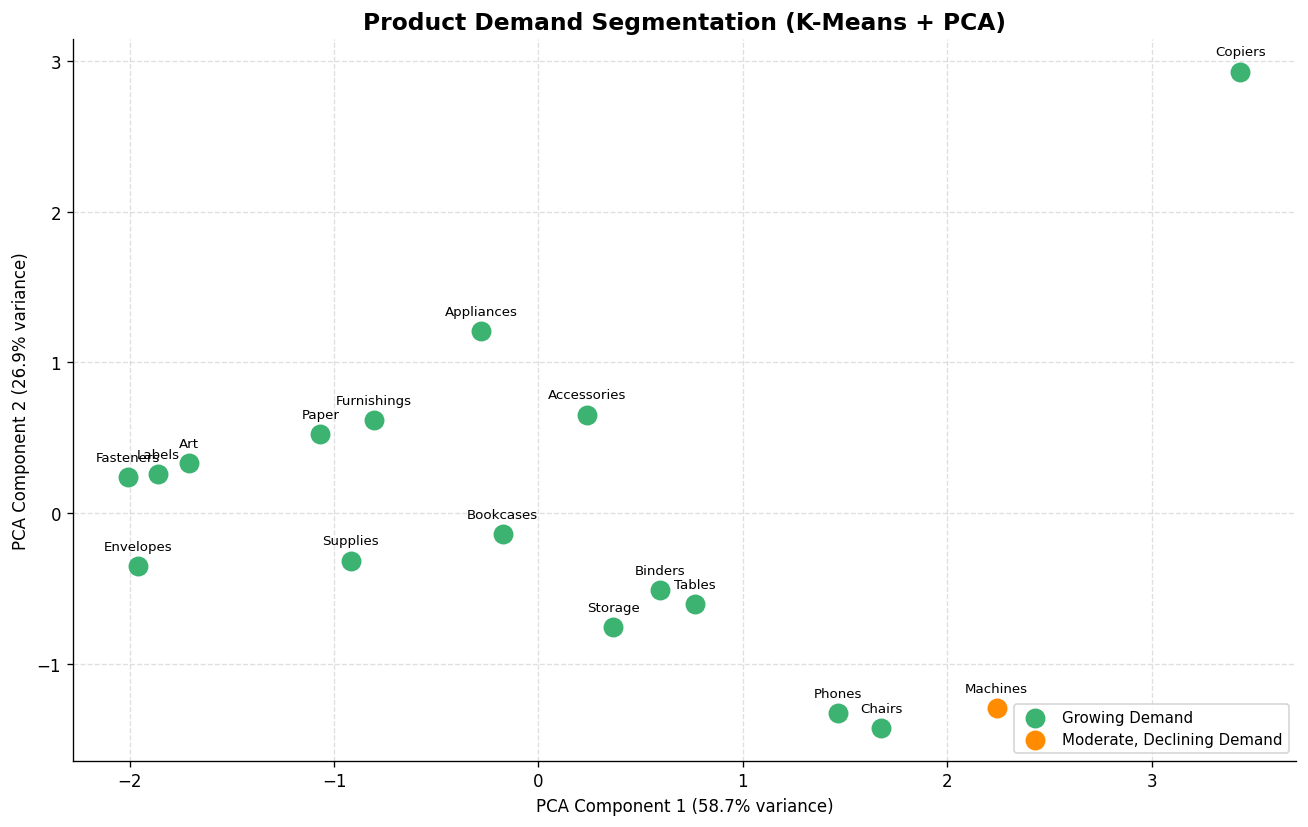

Saved -> charts/product_clusters.png


In [38]:
# ── PCA visualization ─────────────────────────────────────────────────────
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_km)
feat_matrix['PCA1'] = X_pca[:, 0]
feat_matrix['PCA2'] = X_pca[:, 1]

print(f"PCA explained variance: {pca.explained_variance_ratio_.sum()*100:.1f}% of total variance captured")

cluster_colors = {
    'High Volume, Stable Demand':     'steelblue',
    'Growing Demand':                  'mediumseagreen',
    'Low Volume, High Volatility':     'tomato',
    'Moderate, Declining Demand':      'darkorange',
}

fig, ax = plt.subplots(figsize=(11, 7))
for label, group in feat_matrix.groupby('Cluster Label'):
    ax.scatter(group['PCA1'], group['PCA2'],
               color=cluster_colors.get(label, 'gray'),
               s=120, label=label, zorder=3)
    for _, row in group.iterrows():
        ax.annotate(row['Sub-Category'],
                    (row['PCA1'], row['PCA2']),
                    fontsize=8, ha='center', va='bottom',
                    xytext=(0, 8), textcoords='offset points')

ax.set_title('Product Demand Segmentation (K-Means + PCA)',
             fontsize=14, fontweight='bold')
ax.set_xlabel(f'PCA Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
ax.set_ylabel(f'PCA Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
ax.legend(fontsize=9, loc='lower right')
ax.grid(linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('charts/product_clusters.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved -> charts/product_clusters.png")


In [39]:
# ── Stocking strategy per cluster ─────────────────────────────────────────
print("=" * 65)
print("RECOMMENDED STOCKING STRATEGY PER DEMAND CLUSTER")
print("=" * 65)

strategies = {
    'High Volume, Stable Demand':   'Maintain steady, predictable inventory levels. '
                                     'Use just-in-time replenishment. Low risk of overstock.',
    'Growing Demand':               'Increase stock aggressively — 15-20% above last year. '
                                     'Priority for warehouse space allocation.',
    'Low Volume, High Volatility':  'Keep minimal safety stock. Order in small batches. '
                                     'High risk of dead stock if overordered.',
    'Moderate, Declining Demand':   'Gradually reduce inventory. Clear existing stock '
                                     'with promotions. Consider discontinuing slow movers.',
}

for label, strategy in strategies.items():
    subs = feat_matrix[feat_matrix['Cluster Label'] == label]['Sub-Category'].tolist()
    print(f"\n{label}")
    print(f"  Products : {', '.join(subs)}")
    print(f"  Strategy : {strategy}")


RECOMMENDED STOCKING STRATEGY PER DEMAND CLUSTER

High Volume, Stable Demand
  Products : 
  Strategy : Maintain steady, predictable inventory levels. Use just-in-time replenishment. Low risk of overstock.

Growing Demand
  Products : Bookcases, Chairs, Labels, Tables, Storage, Furnishings, Art, Phones, Binders, Appliances, Paper, Accessories, Envelopes, Fasteners, Supplies, Copiers
  Strategy : Increase stock aggressively — 15-20% above last year. Priority for warehouse space allocation.

Low Volume, High Volatility
  Products : 
  Strategy : Keep minimal safety stock. Order in small batches. High risk of dead stock if overordered.

Moderate, Declining Demand
  Products : Machines
  Strategy : Gradually reduce inventory. Clear existing stock with promotions. Consider discontinuing slow movers.


---
## Task 7 — Streamlit Dashboard

The interactive dashboard is built as a **separate file: `app.py`**.

To run it locally:
```bash
streamlit run app.py
```

This will open a browser tab at `http://localhost:8501` with 4 pages:
- **Page 1:** Sales Overview (year/month/region/category charts)
- **Page 2:** Forecast Explorer (select category + horizon)
- **Page 3:** Anomaly Report (anomaly chart + table)
- **Page 4:** Product Demand Segments (cluster chart + table)

See `app.py` in the project folder for the complete dashboard code.


---
## Final Conclusion

| Task | Deliverable | Status |
|------|-------------|--------|
| Task 1 | Data loading, cleaning, 4 business questions answered | Done |
| Task 2 | Decomposition (Trend/Seasonality/Residual) + ADF test | Done |
| Task 3 | SARIMA + Prophet + XGBoost with comparison table | Done |
| Task 4 | 5 segment forecasts (3 categories + 2 regions) | Done |
| Task 5 | Isolation Forest + Z-Score anomaly detection | Done |
| Task 6 | K-Means clustering with PCA visualization | Done |
| Task 7 | Streamlit dashboard (see `app.py`) | Done |
| Task 8 | Executive report (see `summary.docx`) | Done |

**All charts saved to `charts/` folder.**

---
*Internship Project — Week 3 & 4 Submission*
